In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

Created a simulated_realtime_traffic.csv file with AI (Chatgpt).Used python code i..e generate_data.py to create dataset and use this subset for analysing traffic.

In [2]:
df = pd.read_csv("../data/simulated_realtime_traffic.csv")

df.head()

,Timestamp,Road,Station,Kilometer,Lanes,Flow,Speed,Occupancy,Truck_Percentage,Weather,Construction,Accident,Traffic_Jam
0,2023-08-02 00:00:00,A6,A6_Station_1,15,4,935,108,24,19.639879,Clear,0,0,0
1,2023-08-02 00:05:00,A6,A6_Station_1,15,4,830,90,33,11.674172,Clear,0,0,0
2,2023-08-02 00:10:00,A6,A6_Station_1,15,4,843,123,39,9.246782,Clear,0,0,0
3,2023-08-02 00:15:00,A6,A6_Station_1,15,4,521,123,34,10.824583,Clear,0,0,0
4,2023-08-02 00:20:00,A6,A6_Station_1,15,4,1475,94,56,17.367720,Clear,1,0,1


In [ ]:
# Display the number of rows and columns in the DataFrame
print("Rows :", len(df))
print("Columns :", len(df.columns))

df.info()

Rows : 60480
Columns : 13
<class 'pandas.DataFrame'>
RangeIndex: 60480 entries, 0 to 60479
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp         60480 non-null  str    
 1   Road              60480 non-null  str    
 2   Station           60480 non-null  str    
 3   Kilometer         60480 non-null  int64  
 4   Lanes             60480 non-null  int64  
 5   Flow              60480 non-null  int64  
 6   Speed             60480 non-null  int64  
 7   Occupancy         60480 non-null  int64  
 8   Truck_Percentage  60480 non-null  float64
 9   Weather           60480 non-null  str    
 10  Construction      60480 non-null  int64  
 11  Accident          60480 non-null  int64  
 12  Traffic_Jam       60480 non-null  int64  
dtypes: float64(1), int64(8), str(4)
memory usage: 6.0 MB


In [4]:
df.describe()

,Kilometer,Lanes,Flow,Speed,Occupancy,Truck_Percentage,Construction,Accident,Traffic_Jam
count,60480.000000,60480.000000,60480.000000,60480.000000,60480.000000,60480.000000,60480.000000,60480.000000,60480.000000
mean,82.500000,3.166667,1275.349769,90.726108,45.827348,15.024999,0.050231,0.019709,0.086954
std,43.084576,0.819898,544.855531,28.193541,23.865557,5.774268,0.218424,0.139000,0.281771
min,15.000000,2.000000,500.000000,20.000000,10.000000,5.000446,0.000000,0.000000,0.000000
25%,45.000000,2.000000,834.000000,79.750000,26.000000,10.001429,0.000000,0.000000,0.000000
50%,82.500000,3.000000,1165.000000,96.000000,43.000000,15.046866,0.000000,0.000000,0.000000
75%,120.000000,4.000000,1574.250000,113.000000,59.250000,20.042371,0.000000,0.000000,0.000000
max,150.000000,4.000000,2399.000000,129.000000,99.000000,24.998875,1.000000,1.000000,1.000000


# Rule-Based Traffic Jam Detection

A traffic jam is detected if:

- Speed < 30 km/h AND Occupancy > 80%

OR

- Construction is present

OR

- Accident is reported


In [5]:
df["Predicted_Jam"] = (
    ((df["Speed"] < 30) & (df["Occupancy"] > 80))
    |
    (df["Construction"] == 1)
    |
    (df["Accident"] == 1)
)

In [6]:
jam = df[df["Predicted_Jam"]]

jam.head()

,Timestamp,Road,Station,Kilometer,Lanes,Flow,Speed,Occupancy,Truck_Percentage,Weather,Construction,Accident,Traffic_Jam,Predicted_Jam
4,2023-08-02 00:20:00,A6,A6_Station_1,15,4,1475,94,56,17.367720,Clear,1,0,1,True
40,2023-08-02 03:20:00,A6,A6_Station_1,15,4,1328,127,28,16.440084,Rain,0,1,1,True
70,2023-08-02 05:50:00,A6,A6_Station_1,15,4,1414,91,18,11.386273,Snow,1,0,1,True
73,2023-08-02 06:05:00,A6,A6_Station_1,15,4,632,114,32,15.918315,Rain,1,0,1,True
75,2023-08-02 06:15:00,A6,A6_Station_1,15,4,1445,106,11,6.626976,Clear,1,0,1,True


In [ ]:
#Traffic jam severity
#AI usage : if there is accident make it critical,if there is construtcion make it high, if speed is less than 20 make it high, if speed is less than 30 make it medium, else make it low to find severity
def severity(row):

    if row["Accident"] == 1:
        return "Critical"

    elif row["Construction"] == 1:
        return "High"

    elif row["Speed"] < 20:
        return "High"

    elif row["Speed"] < 30:
        return "Medium"

    else:
        return "Low"

df["Severity"] = df.apply(severity, axis=1)

df.head()

,Timestamp,Road,Station,Kilometer,Lanes,Flow,Speed,Occupancy,Truck_Percentage,Weather,Construction,Accident,Traffic_Jam,Predicted_Jam,Severity
0,2023-08-02 00:00:00,A6,A6_Station_1,15,4,935,108,24,19.639879,Clear,0,0,0,False,Low
1,2023-08-02 00:05:00,A6,A6_Station_1,15,4,830,90,33,11.674172,Clear,0,0,0,False,Low
2,2023-08-02 00:10:00,A6,A6_Station_1,15,4,843,123,39,9.246782,Clear,0,0,0,False,Low
3,2023-08-02 00:15:00,A6,A6_Station_1,15,4,521,123,34,10.824583,Clear,0,0,0,False,Low
4,2023-08-02 00:20:00,A6,A6_Station_1,15,4,1475,94,56,17.367720,Clear,1,0,1,True,High


In [8]:
df["Severity"].value_counts()

Severity
Low         54042
High         2977
Medium       2269
Critical     1192
Name: count, dtype: int64

# Number of Traffic Jams by Road

In [9]:
road_jams = (

df[df["Predicted_Jam"]]

.groupby("Road")

.size()

)

road_jams

Road
A6     1769
A9     1737
A93    1753
dtype: int64

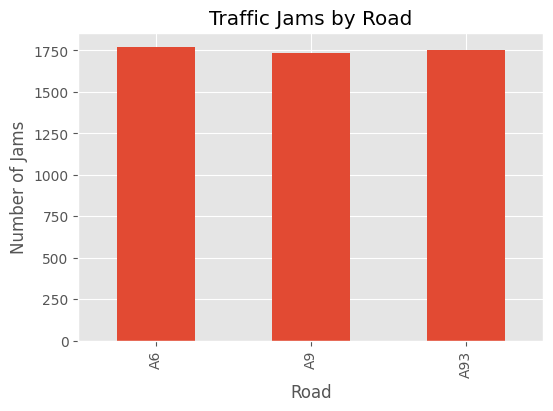

In [10]:
road_jams.plot(
    kind="bar",
    figsize=(6,4),
    title="Traffic Jams by Road"
)

plt.ylabel("Number of Jams")
plt.show()

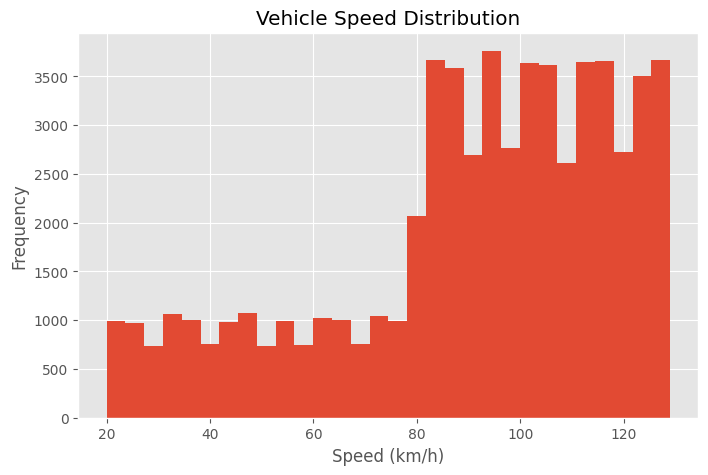

In [ ]:
#traffic jams distribution
#AI usage : I want to create a histogram to visualize the distribution of vehicle speeds in the traffic data.
plt.figure(figsize=(8,5))

plt.hist(df["Speed"], bins=30)

plt.title("Vehicle Speed Distribution")

plt.xlabel("Speed (km/h)")

plt.ylabel("Frequency")

plt.show()

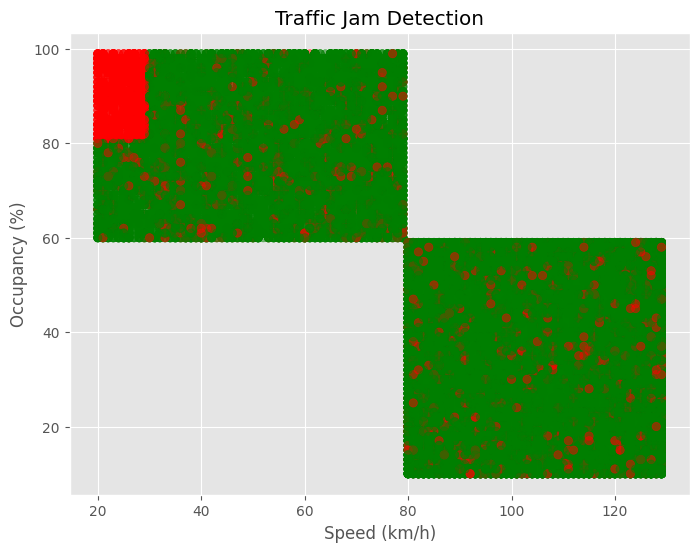

In [ ]:
#speed vs occupancy scatter plot
#AI usgage : I want to show traffic jam detection using a scatter plot of speed vs occupancy, with points colored based on whether a jam is predicted or not.
colors = df["Predicted_Jam"].map({True:"red",False:"green"})

plt.figure(figsize=(8,6))

plt.scatter(
    df["Speed"],
    df["Occupancy"],
    c=colors,
    alpha=0.5
)

plt.xlabel("Speed (km/h)")
plt.ylabel("Occupancy (%)")
plt.title("Traffic Jam Detection")

plt.show()

In [13]:
#top 10 jam locations
top = (

jam

.groupby(["Road","Station"])

.size()

.reset_index(name="Jam_Count")

.sort_values("Jam_Count",ascending=False)

.head(10)

)

top

,Road,Station,Jam_Count
22,A93,A93_Station_2,201
9,A6,A6_Station_9,198
11,A9,A9_Station_10,195
8,A6,A6_Station_8,191
1,A6,A6_Station_10,186
13,A9,A9_Station_3,186
18,A9,A9_Station_8,186
26,A93,A93_Station_6,186
20,A93,A93_Station_1,186
21,A93,A93_Station_10,185


In [14]:
top.to_csv(
    "../results/top_jam_locations.csv",
    index=False
)

AI prompt (gpt) : give me final conclusion of this notebook

# Project Conclusion

The simulated dataset demonstrates how real-time traffic jams can be detected using a simple rule-based approach.

The algorithm considers:

- Low vehicle speed
- High road occupancy
- Construction activities
- Accident reports

Although the original BASt dataset only provides annual traffic statistics, this extension illustrates how the methodology could be adapted for real-time intelligent traffic monitoring systems.